<h1>Model potpuno povezane neuronske mreže</h1>
<h2>Uvođenje potrebnih paketa</h2>

In [237]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [238]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

In [239]:
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import metrics

In [240]:
import keras

In [241]:
import os
import random

Kako bi se model mogao reprodukovati koristi se sledeća ćelija

In [242]:
seed_value = 7

os.environ["PYTHONHASHSEED"] = str(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"  

random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

<h2>Učitavanje pretprocesiranih podataka</h2>

In [243]:
data = pd.read_csv('preprocessed_data.csv', index_col=0)

In [244]:
data.head()

,Bachelor's,Intermediate,Master's,Matric,PhD,Finance,Science,Business,Computer Science,Arts,...,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage,Recommended Career
0,1,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,67,Business Analyst
1,0,1,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,67,Software Engineer
2,0,0,1,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,90,Financial Analyst
3,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,75,Clerk
4,0,0,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,83,Sales Assistant


In [245]:
target = 'Recommended Career'

<h2>Izdvajanje atributa</h2>

In [246]:
x = data.drop(target, axis=1)
number_of_features = x.shape[1]
number_of_features

31

In [247]:
x.head()

,Bachelor's,Intermediate,Master's,Matric,PhD,Finance,Science,Business,Computer Science,Arts,...,Python,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage
0,1,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,67
1,0,1,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,67
2,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,90
3,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,75
4,0,0,0,1,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,83


<h2>Izdvajanje i label enkodovanje ciljne promenljive</h2>

In [248]:
y = data[target]
y.head()

0     Business Analyst
1    Software Engineer
2    Financial Analyst
3                Clerk
4      Sales Assistant
Name: Recommended Career, dtype: str

In [249]:
number_of_classes = len(y.unique())

In [250]:
target_names = data[target].unique()

y = data[target]

label_encoder = preprocessing.LabelEncoder()
y_encoded = label_encoder.fit_transform( data[target] )

y_encoded

array([ 0, 11,  3, ...,  3, 11,  1], shape=(5000,))

In [251]:
y

0        Business Analyst
1       Software Engineer
2       Financial Analyst
3                   Clerk
4         Sales Assistant
              ...        
4995                Clerk
4996     School Counselor
4997    Financial Analyst
4998    Software Engineer
4999                Clerk
Name: Recommended Career, Length: 5000, dtype: str

<h2>Podela podataka na skupove za treniranje i testiranje i standardizacija</h2>
U opštem slučaju se vrši podela podataka na skup nad kojim će model trenirati(trening skup), skup nad kojim će se vršiti evaluacija modela u cilju izbora optimalnih parametara(validacioni skup) i skup koji će se koristiti za evaluaciju modela i davanje konačne ocene tog modela(test skup), ali kako sami modeli neuronskih mreža omogućavaju podelu trening skupa na skup za treniranje i validaciju nju nije potrebno ručno izvršavati. Podela se vrši pomoću funkcije train_test_split pri čemu uzimamo trećinu podataka za skup za testiranje. Takođe vodimo računa o stratifikaciji da bi udeo klasa ciljne promenljive u skupu za treniranje i testiranje bio procentualno jednak. Parametar random_state postavljamo na vrednost 7 kako bi se model mogao reprodukovati.

In [252]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y_encoded, test_size=0.33, stratify=y, random_state=7)

In [253]:
scaler = preprocessing.StandardScaler()

In [254]:
scaler.fit(x_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [255]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

<h2>Pretvaranje ciljne promenljive u oblik koji je pogodan za model neuronskih mreža</h2>

In [256]:
y_train = to_categorical(y_train, number_of_classes)
y_test = to_categorical(y_test, number_of_classes)

<h2>Pravljenje i treniranje modela potpuno povezanih neuronskih mreža</h2>
Uključivanje dodatnih paketa potrebnih za model neuronskih mreža

In [257]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense
from tensorflow.keras.optimizers import Adam

In [258]:
model = Sequential()

In [259]:
model.add(InputLayer(shape=(number_of_features,)))
model.add(Dense(units=15, activation='relu'))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=number_of_classes, activation='softmax'))

In [260]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 15)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 12)             │           108 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 716 (2.80 KB)

 Trainable params: 716 (2.80 KB)

 Non-trainable params: 0 (0.00 B)

In [261]:
learning_rate = 0.001
number_of_epochs = 50
batch_size = 32

Za funkciju gubitka smo izabrali kategoričku unakrsnu entropiju, a za optimizator Adam sa parametrom learning_rate=0.001

In [262]:
model.compile(loss = 'categorical_crossentropy', optimizer=Adam(learning_rate), metrics=['accuracy'])

In [263]:
history = model.fit(x_train, y_train, epochs=number_of_epochs, batch_size=batch_size,validation_split=0.2)

Epoch 1/50


2026-03-03 13:05:04.395879: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0780 - loss: 2.5470 - val_accuracy: 0.0925 - val_loss: 2.5203
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step - accuracy: 0.0866 - loss: 2.5043 - val_accuracy: 0.0821 - val_loss: 2.5062
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - accuracy: 0.0963 - loss: 2.4880 - val_accuracy: 0.0791 - val_loss: 2.5018
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - accuracy: 0.1015 - loss: 2.4793 - val_accuracy: 0.0687 - val_loss: 2.5006
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.1075 - loss: 2.4739 - val_accuracy: 0.0687 - val_loss: 2.5005
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - accuracy: 0.1123 - loss: 2.4700 - val_accuracy: 0.0687 - val_loss: 2.5005
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - accuracy: 0.1164 - loss: 2.4664 - val_accuracy: 0.0672 - val_loss: 2.5008
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - accuracy: 0.1209 - loss: 2.4630 - val_accuracy: 0.0746 - val_lo

Prikazivanje procesa treniranja pomoću grafika

In [264]:
epochs = history.epoch
loss = history.history['loss']
validation_loss = history.history['val_loss']

acc = history.history['accuracy']
validation_acc = history.history['val_accuracy']

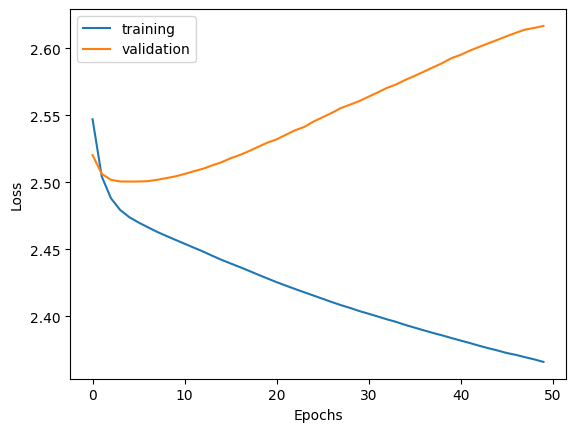

In [265]:
plt.plot(epochs, loss, label='training')
plt.plot(epochs, validation_loss, label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

In [266]:
history.history['val_accuracy']

[0.09253731369972229,
 0.08208955079317093,
 0.0791044756770134,
 0.06865671277046204,
 0.06865671277046204,
 0.06865671277046204,
 0.06716418266296387,
 0.0746268630027771,
 0.07761193811893463,
 0.07761193811893463,
 0.07761193811893463,
 0.07761193811893463,
 0.07313432544469833,
 0.0701492503285408,
 0.06865671277046204,
 0.0701492503285408,
 0.07164178788661957,
 0.06417910754680634,
 0.0656716451048851,
 0.06865671277046204,
 0.0656716451048851,
 0.06417910754680634,
 0.0656716451048851,
 0.0656716451048851,
 0.0656716451048851,
 0.0701492503285408,
 0.0701492503285408,
 0.06865671277046204,
 0.0701492503285408,
 0.07164178788661957,
 0.07164178788661957,
 0.07313432544469833,
 0.07611940056085587,
 0.07313432544469833,
 0.0746268630027771,
 0.07611940056085587,
 0.07313432544469833,
 0.07611940056085587,
 0.07313432544469833,
 0.0746268630027771,
 0.0746268630027771,
 0.0746268630027771,
 0.07313432544469833,
 0.0746268630027771,
 0.07313432544469833,
 0.07313432544469833,
 0.07

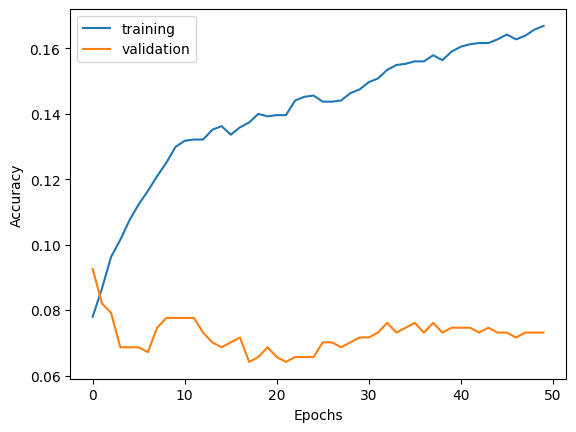

In [267]:
plt.plot(epochs, acc, label='training')
plt.plot(epochs, validation_acc, label='validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()

Vidimo da je model počeo da se preprilagođava već nakon treće epohe

In [268]:
train_score = model.evaluate(x_train, y_train)
train_score

105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.1513 - loss: 2.4095


[2.409477710723877, 0.15134328603744507]

In [269]:
train_score = model.evaluate(x_test, y_test)
train_score

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - accuracy: 0.0800 - loss: 2.5824


[2.5824148654937744, 0.07999999821186066]

Na osnovu rezultata vidimo da ni model potpuno povezanih neuronskih mreža nije uspeo da nauči zavisnost između atributa i ciljne promenljive pa na osnovu ovog i prethodnih rezultata zaključujemo da zavisnost između atributa i ciljne promenljive najverovatnije i ne postoji. Kako bismo se uverili u to sami smo pogledali skup podataka kako bismo proverili da li se i mi sami slažemo sa preporukama karijere na osnovu poznatih atributa. Na kraju ove sveske daćemo i par nama nelogičnih instanci (iako ih u skupu podataka ima mnogo više)

U nastavku dajemo i ostale metrike koje su prikazivane i za ostale modele

In [270]:
y_test_classes = np.argmax(y_test, axis=1)
y_test_classes

array([5, 1, 5, ..., 5, 1, 7], shape=(1650,))

In [271]:
y_test_predicted = model.predict(x_test)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step


2026-03-03 13:05:09.428562: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [272]:
y_test_predicted

array([[0.06281805, 0.08373754, 0.11533629, ..., 0.07427661, 0.10651196,
        0.09498438],
       [0.05447225, 0.06727251, 0.14157923, ..., 0.10622051, 0.06239545,
        0.10091148],
       [0.08426923, 0.10261296, 0.0724081 , ..., 0.07586838, 0.06184142,
        0.08876052],
       ...,
       [0.07098115, 0.06580979, 0.10405106, ..., 0.06939256, 0.09427164,
        0.10150962],
       [0.05847864, 0.1179207 , 0.06374748, ..., 0.08372797, 0.07943227,
        0.09506862],
       [0.06786962, 0.07232451, 0.09662828, ..., 0.07190344, 0.09357424,
        0.10126837]], shape=(1650, 12), dtype=float32)

In [273]:
y_test_predicted_classes = np.argmax(y_test_predicted,axis=1)
y_test_predicted_classes

array([2, 2, 5, ..., 5, 5, 5], shape=(1650,))

In [274]:
y_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1650, 12))

In [275]:
cm = metrics.confusion_matrix(y_test_classes, y_test_predicted_classes)
cm

array([[ 2, 24, 14,  8,  5, 32,  6,  8,  3,  3, 18,  7],
       [ 3, 17, 14, 16,  2, 47, 10,  6,  4,  0, 20,  4],
       [ 1, 29, 14, 13,  1, 29, 10, 10,  3,  5, 16,  5],
       [ 0, 21, 17, 18,  2, 43,  6,  6,  4,  1, 12,  6],
       [ 1, 25, 16, 16,  3, 38,  6,  8,  7,  1, 14,  1],
       [ 1, 20, 21, 16,  3, 43,  6,  7,  2,  3, 15,  5],
       [ 1, 21, 17, 10,  1, 42,  4,  9,  3,  1, 27,  7],
       [ 0, 24, 13, 19,  2, 33,  9,  4,  3,  2, 19,  6],
       [ 2, 22, 14, 16,  2, 48,  8,  8,  2,  1, 11,  4],
       [ 1,  9, 19, 23,  3, 36,  7,  1,  5,  2, 22,  8],
       [ 2, 18, 12, 14,  1, 47,  7,  9,  6,  0, 15,  7],
       [ 3, 15, 15, 14,  2, 37,  6,  6, 11,  4, 17,  8]])

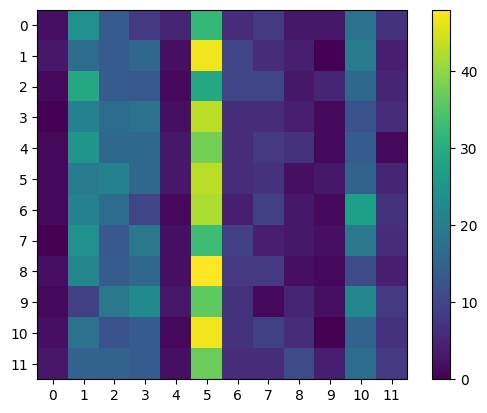

In [276]:
plt.imshow(cm)
plt.colorbar()
plt.xticks(np.arange(number_of_classes))
plt.yticks(np.arange(number_of_classes))
plt.show()

In [277]:
print(metrics.classification_report(y_test_classes, y_test_predicted_classes))

              precision    recall  f1-score   support

           0       0.12      0.02      0.03       130
           1       0.07      0.12      0.09       143
           2       0.08      0.10      0.09       136
           3       0.10      0.13      0.11       136
           4       0.11      0.02      0.04       136
           5       0.09      0.30      0.14       142
           6       0.05      0.03      0.04       143
           7       0.05      0.03      0.04       134
           8       0.04      0.01      0.02       138
           9       0.09      0.01      0.03       136
          10       0.07      0.11      0.09       138
          11       0.12      0.06      0.08       138

    accuracy                           0.08      1650
   macro avg       0.08      0.08      0.06      1650
weighted avg       0.08      0.08      0.06      1650

